<a href="https://colab.research.google.com/github/Eve-Yatzkan/Image_proccessing_project/blob/main/notebooks/04_image_enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Eve-Yatzkan/Image_proccessing_project.git


Cloning into 'Image_proccessing_project'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 112 (delta 31), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (112/112), 45.96 MiB | 18.95 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [ ]:
# התקנת הספריות הדרושות
!pip install -q opencv-python matplotlib numpy pandas torch torchvision ultralytics albumentations

%cd /content/Image_proccessing_project

import random
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

from torchvision.datasets import VOCSegmentation
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from ultralytics import YOLO

# הגדרות שחזור מדוייקות למחברות הקודמות
SEED = 10
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Computation device:", DEVICE)

# הגדרת נתיבים
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.2 MB/s eta 0:00:00
/content/Image_proccessing_project
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Computation device: cuda


In [ ]:
def restore_noise(img_rgb):
    # המרה ל-BGR כי OpenCV עובד בפורמט הזה
    bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    # הפעלת מסנן Denoising חזק
    den = cv2.fastNlMeansDenoisingColored(bgr, None, 25, 25, 7, 35)

    # מעבר נוסף עם Bilateral Filter להחלקת שאריות הרעש
    den = cv2.bilateralFilter(den, d=9, sigmaColor=80, sigmaSpace=80)

    out = cv2.cvtColor(den, cv2.COLOR_BGR2RGB)
    return out

def restore_jpeg(img_rgb):
    # המרה למרחב צבעים YCrCb שעוזר להפריד בין תאורה לצבע
    ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycrcb)

    # הפעלת הפילטר רק על ערוץ התאורה (Y)
    y = cv2.bilateralFilter(y, d=7, sigmaColor=40, sigmaSpace=40)

    out = cv2.cvtColor(cv2.merge([y, cr, cb]), cv2.COLOR_YCrCb2RGB)
    return out

def restore_lowlight(img_rgb):
    # תיקון גאמה
    gamma = 0.35
    lut = (np.arange(256) / 255.0) ** gamma * 255
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    img_gamma = cv2.LUT(img_rgb, lut)

    # הפעלת CLAHE על ערוץ התאורה במרחב LAB
    lab = cv2.cvtColor(img_gamma, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=6.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    out = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)
    return out

print("Enhancement functions loaded successfully.")


Enhancement functions loaded successfully.


In [ ]:
# טעינת הדאטאסט והאינדקסים (עם אישור הורדה מחדש למכונה הזמנית)
dataset = VOCSegmentation(root=DATA_DIR, year="2012", image_set="train", download=True)

selected_indices_path = RESULTS_DIR / "selected_indices.csv"
selected_indices_df = pd.read_csv(selected_indices_path)
selected_indices = selected_indices_df["dataset_index"].tolist()

print(f"Loaded {len(selected_indices)} images for enhancement testing.")



100%|██████████| 2.00G/2.00G [01:48<00:00, 18.5MB/s]


Loaded 100 images for enhancement testing.


In [ ]:
# התקנת הספריות (למקרה שגוגל קולאב התאפס ומחק אותן)
!pip install -q opencv-python matplotlib numpy pandas torch torchvision ultralytics albumentations

import cv2
import numpy as np
import torch
from ultralytics import YOLO
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

# הגדרות (כדי למנוע שגיאות במקרה של ניתוק)
SEED = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# פונקציות העיוות המדויקות של מעיין (רמת Severe)
def apply_gaussian_noise(img_pil, sigma=50, seed=SEED):
    img_np = np.array(img_pil.convert("RGB"), dtype=np.float32)
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0.0, scale=sigma, size=img_np.shape)
    noisy_img = np.clip(img_np + noise, 0, 255).astype(np.uint8)
    return noisy_img

def apply_jpeg_compression(img_pil, quality=5):
    img_np = np.array(img_pil.convert("RGB"))
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    result, encimg = cv2.imencode('.jpg', cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR), encode_param)
    decimg = cv2.imdecode(encimg, 1)
    return cv2.cvtColor(decimg, cv2.COLOR_BGR2RGB)

def apply_low_light(img_pil, factor=0.15):
    img_np = np.array(img_pil.convert("RGB"), dtype=np.float32)
    dark_img = np.clip(img_np * factor, 0, 255).astype(np.uint8)
    return dark_img

# טעינת המודלים (YOLO, SegFormer, ORB)
ORB_NFEATURES = 1500
orb = cv2.ORB_create(nfeatures=ORB_NFEATURES)

yolo_model = YOLO("yolo11n.pt")

weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = deeplabv3_resnet50(weights=weights).to(DEVICE)
seg_model.eval()
seg_transforms = weights.transforms()

print("Custom Distortions (Maayan's Config) and Models loaded successfully.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 167MB/s]


Custom Distortions (Maayan's Config) and Models loaded successfully.


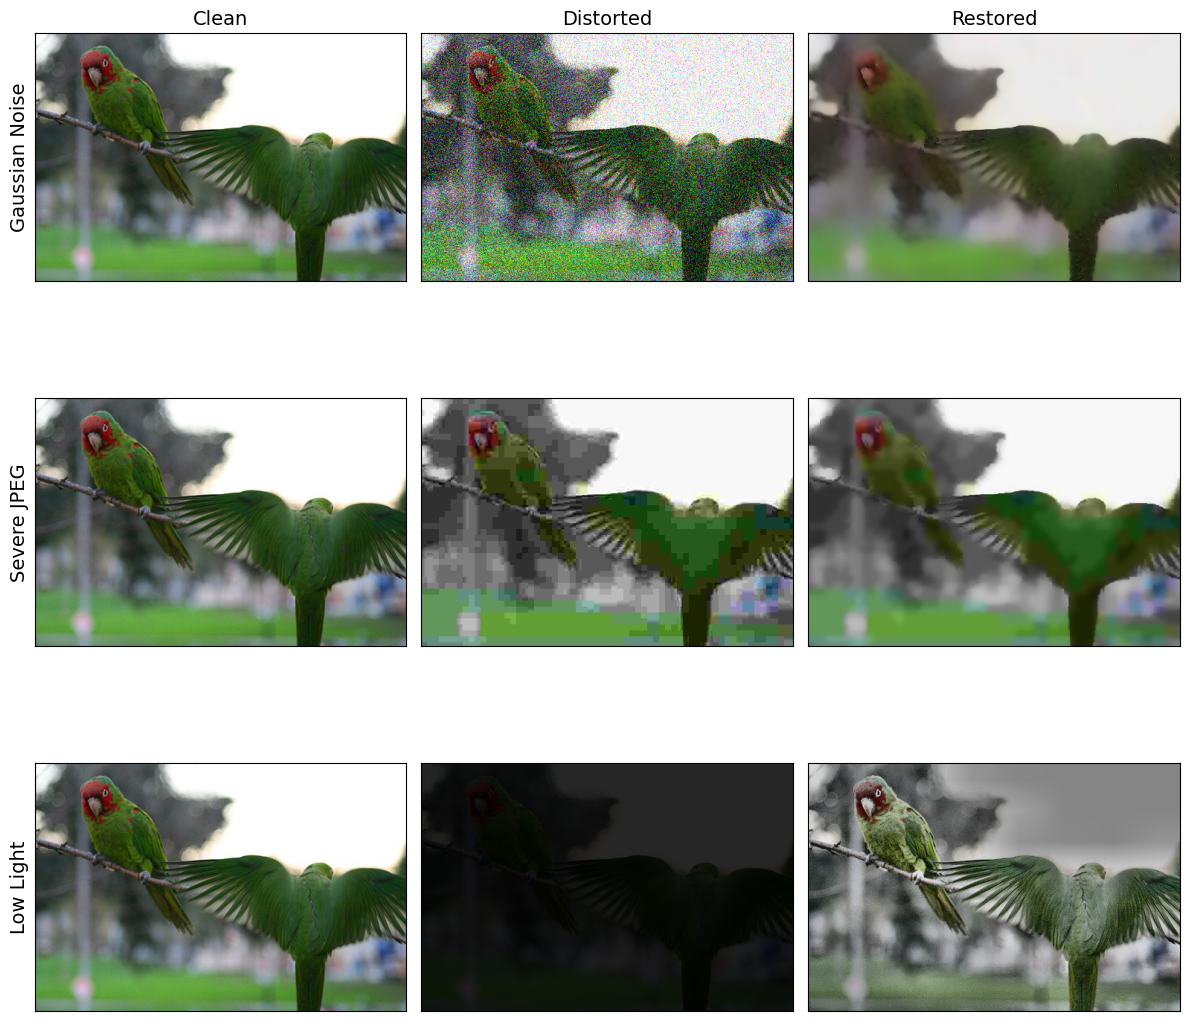

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torchvision.datasets import VOCSegmentation

# 1. הגדרות נתיבים
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 10

# 2. פונקציות העיוות של מעיין (Severe)
def apply_gaussian_noise(img_pil, sigma=50, seed=SEED):
    img_np = np.array(img_pil.convert("RGB"), dtype=np.float32)
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0.0, scale=sigma, size=img_np.shape)
    return np.clip(img_np + noise, 0, 255).astype(np.uint8)

def apply_jpeg_compression(img_pil, quality=5):
    img_np = np.array(img_pil.convert("RGB"))
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    result, encimg = cv2.imencode('.jpg', cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR), encode_param)
    decimg = cv2.imdecode(encimg, 1)
    return cv2.cvtColor(decimg, cv2.COLOR_BGR2RGB)

def apply_low_light(img_pil, factor=0.15):
    img_np = np.array(img_pil.convert("RGB"), dtype=np.float32)
    return np.clip(img_np * factor, 0, 255).astype(np.uint8)

# 3. פונקציות השחזור (Image Enhancements)
def restore_noise(img_np):
    bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    den = cv2.fastNlMeansDenoisingColored(bgr, None, 25, 25, 7, 35)
    den = cv2.bilateralFilter(den, d=9, sigmaColor=80, sigmaSpace=80)
    return cv2.cvtColor(den, cv2.COLOR_BGR2RGB)

def restore_jpeg(img_np):
    # הפעלה אגרסיבית של הפילטר על כל מרחב הצבעים כדי "לשבור" את הבלוקים של ה-JPEG
    out = cv2.bilateralFilter(img_np, d=15, sigmaColor=100, sigmaSpace=100)
    return out

def restore_lowlight(img_np):
    gamma = 0.35
    lut = (np.arange(256) / 255.0) ** gamma * 255
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    img_gamma = cv2.LUT(img_np, lut)
    lab = cv2.cvtColor(img_gamma, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=6.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)

# 4. טעינת הנתונים (כולל מנגנון הגיבוי של מעיין)
dataset = VOCSegmentation(root=DATA_DIR, year="2012", image_set="train", download=True)
selected_indices_path = RESULTS_DIR / "selected_indices.csv"

if selected_indices_path.exists():
    selected_indices_df = pd.read_csv(selected_indices_path)
    selected_indices = selected_indices_df["dataset_index"].tolist()
else:
    # יצירת המדגם מחדש באופן זהה לחלוטין אם הקובץ נמחק
    rng = np.random.default_rng(SEED)
    selected_indices = sorted(rng.choice(len(dataset), size=100, replace=False).tolist())

# 5. בחירת תמונה והפעלת הכל
sample_idx = selected_indices[0]
sample_img, _ = dataset[sample_idx]

# עיוות
noisy_img_np = apply_gaussian_noise(sample_img)
jpeg_img_np = apply_jpeg_compression(sample_img)
dark_img_np = apply_low_light(sample_img)

# שחזור
restored_noisy = restore_noise(noisy_img_np)
restored_jpeg = restore_jpeg(jpeg_img_np)
restored_dark = restore_lowlight(dark_img_np)

# 6. יצירת גריד ההשוואה
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
row_labels = ['Gaussian Noise', 'Severe JPEG', 'Low Light']

sample_img_np = np.array(sample_img)
distorted_imgs = [noisy_img_np, jpeg_img_np, dark_img_np]
restored_imgs = [restored_noisy, restored_jpeg, restored_dark]

for i in range(3):
    axes[i, 0].imshow(sample_img_np)
    if i == 0: axes[i, 0].set_title("Clean", fontsize=14)
    axes[i, 0].set_ylabel(row_labels[i], fontsize=14)

    axes[i, 1].imshow(distorted_imgs[i])
    if i == 0: axes[i, 1].set_title("Distorted", fontsize=14)

    axes[i, 2].imshow(restored_imgs[i])
    if i == 0: axes[i, 2].set_title("Restored", fontsize=14)

for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


Starting ORB evaluation on 100 images... This might take a minute or two.

--- ORB Matching Results (Mean across 100 images) ---
GaussNoise: Distorted = 0.429, Enhanced = 0.249
SevereJPEG: Distorted = 0.380, Enhanced = 0.341
LowLight: Distorted = 0.085, Enhanced = 0.281


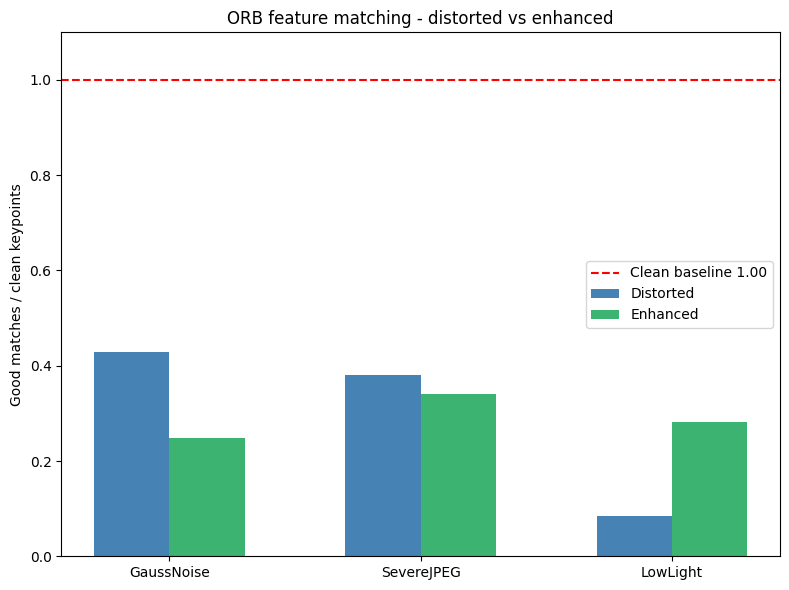

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# הגדרת ORB והמתאים (Matcher) בדיוק לפי ההגדרות של מעיין
orb = cv2.ORB_create(nfeatures=1500)
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

# מילון לשמירת התוצאות של 100 התמונות
results = {
    "GaussNoise": {"distorted": [], "enhanced": []},
    "SevereJPEG": {"distorted": [], "enhanced": []},
    "LowLight": {"distorted": [], "enhanced": []}
}

print("Starting ORB evaluation on 100 images... This might take a minute or two.")

# מעבר על כל 100 התמונות
for idx in selected_indices:
    img_pil, _ = dataset[idx]
    img_clean = np.array(img_pil.convert("RGB"))
    gray_clean = cv2.cvtColor(img_clean, cv2.COLOR_RGB2GRAY)

    # חישוב נקודות עניין בתמונה הנקייה (הבסיס שלנו)
    kp_clean, des_clean = orb.detectAndCompute(gray_clean, None)

    if des_clean is None or len(kp_clean) == 0:
        continue

    # רשימת העיוותים ופונקציות השחזור התואמות
    dist_rest_funcs = [
        ("GaussNoise", apply_gaussian_noise, restore_noise),
        ("SevereJPEG", apply_jpeg_compression, restore_jpeg),
        ("LowLight", apply_low_light, restore_lowlight)
    ]

    for dist_name, dist_func, rest_func in dist_rest_funcs:
        # יצירת תמונה מעוותת ותמונה משוחזרת
        img_dist = dist_func(img_pil)
        img_enh = rest_func(img_dist)

        # המרה לאפור לטובת ORB
        gray_dist = cv2.cvtColor(img_dist, cv2.COLOR_RGB2GRAY)
        gray_enh = cv2.cvtColor(img_enh, cv2.COLOR_RGB2GRAY)

        # זיהוי נקודות בתמונות החדשות
        _, des_dist = orb.detectAndCompute(gray_dist, None)
        _, des_enh = orb.detectAndCompute(gray_enh, None)

        # פונקציה פנימית לחישוב יחס ההתאמה (Ratio Test = 0.75)
        def get_match_ratio(des1, des2):
            if des1 is None or len(des1) == 0 or des2 is None or len(des2) < 2:
                return 0.0
            matches = bf.knnMatch(des1, des2, k=2)
            good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]
            return len(good_matches) / len(des1)

        # שמירת התוצאות
        results[dist_name]["distorted"].append(get_match_ratio(des_clean, des_dist))
        results[dist_name]["enhanced"].append(get_match_ratio(des_clean, des_enh))

# חישוב הממוצעים לכל ה-100 תמונות
mean_results = {
    name: {
        "distorted": np.mean(data["distorted"]),
        "enhanced": np.mean(data["enhanced"])
    } for name, data in results.items()
}

print("\n--- ORB Matching Results (Mean across 100 images) ---")
for name, data in mean_results.items():
    print(f"{name}: Distorted = {data['distorted']:.3f}, Enhanced = {data['enhanced']:.3f}")

# ציור הגרף (Bar Plot)
labels = list(mean_results.keys())
dist_means = [mean_results[l]["distorted"] for l in labels]
enh_means = [mean_results[l]["enhanced"] for l in labels]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, dist_means, width, label='Distorted', color='steelblue')
ax.bar(x + width/2, enh_means, width, label='Enhanced', color='mediumseagreen')

# קו אדום שמייצג את התמונה הנקייה המקורית (100% התאמה)
ax.axhline(y=1.0, color='r', linestyle='--', label='Clean baseline 1.00')

ax.set_ylabel('Good matches / clean keypoints')
ax.set_title('ORB feature matching - distorted vs enhanced')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend()

plt.tight_layout()
plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Starting YOLO evaluation on 100 images...

--- YOLO Detection Recall Results (Mean) ---
GaussNoise: Distorted = 0.198, Enhanced = 0.241
SevereJPEG: Distorted = 0.069, Enhanced = 0.316
LowLight: Distorted = 0.696, Enhanced = 0.809


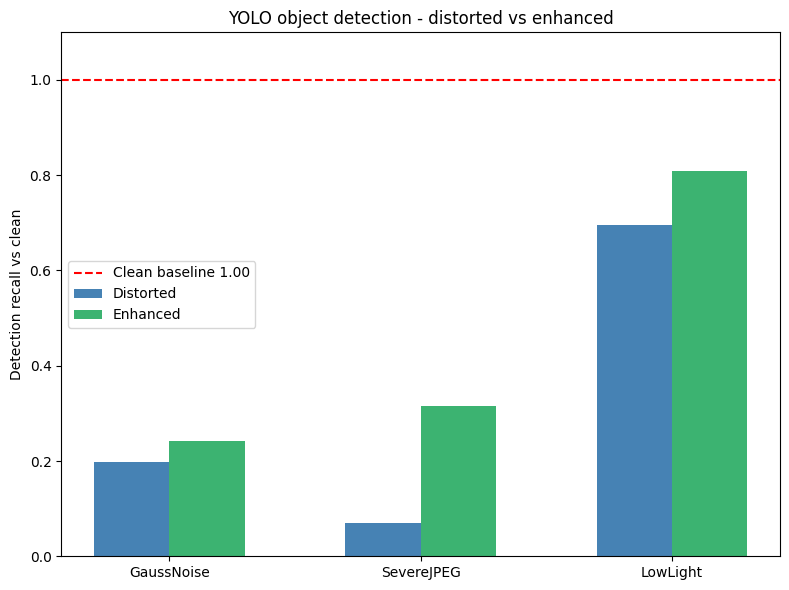

In [9]:
# התקנה מהירה של הספרייה החסרה (למקרה שקולאב התאפס)
!pip install -q ultralytics

import torch
import torchvision.ops as ops
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# טעינת מודל YOLO
yolo_model = YOLO("yolo11n.pt")

# מילון לשמירת תוצאות ה-Recall של YOLO
yolo_results = {
    "GaussNoise": {"distorted": [], "enhanced": []},
    "SevereJPEG": {"distorted": [], "enhanced": []},
    "LowLight": {"distorted": [], "enhanced": []}
}

def compute_recall(clean_res, test_res, iou_thresh=0.5):
    # שליפת הקופסאות והמחלקות מהתוצאות של YOLO
    clean_boxes = clean_res.boxes.xyxy.cpu()
    clean_cls = clean_res.boxes.cls.cpu()
    test_boxes = test_res.boxes.xyxy.cpu()
    test_cls = test_res.boxes.cls.cpu()

    if len(clean_boxes) == 0:
        return 1.0 if len(test_boxes) == 0 else 0.0
    if len(test_boxes) == 0:
        return 0.0

    # חישוב מטריצת חפיפה (IoU) בין כל הקופסאות
    ious = ops.box_iou(clean_boxes, test_boxes)

    matched = 0
    used_test_indices = set()

    # עבור כל אובייקט בתמונה הנקייה, נחפש התאמה בתמונת המבחן
    for i, c_cls in enumerate(clean_cls):
        best_iou = 0
        best_idx = -1
        for j, t_cls in enumerate(test_cls):
            if j in used_test_indices or c_cls != t_cls:
                continue
            if ious[i, j] > best_iou:
                best_iou = ious[i, j].item()
                best_idx = j

        if best_iou >= iou_thresh:
            matched += 1
            used_test_indices.add(best_idx)

    return matched / len(clean_boxes)

print("Starting YOLO evaluation on 100 images...")

for idx in selected_indices:
    img_pil, _ = dataset[idx]

    # ריצת המודל על התמונה הנקייה (הבסיס שלנו)
    res_clean = yolo_model.predict(img_pil, verbose=False)[0]

    dist_rest_funcs = [
        ("GaussNoise", apply_gaussian_noise, restore_noise),
        ("SevereJPEG", apply_jpeg_compression, restore_jpeg),
        ("LowLight", apply_low_light, restore_lowlight)
    ]

    for dist_name, dist_func, rest_func in dist_rest_funcs:
        img_dist = dist_func(img_pil)
        img_enh = rest_func(img_dist)

        # ריצת YOLO על המעוות והמשוחזר
        res_dist = yolo_model.predict(img_dist, verbose=False)[0]
        res_enh = yolo_model.predict(img_enh, verbose=False)[0]

        # חישוב ושמירת ה-Recall
        yolo_results[dist_name]["distorted"].append(compute_recall(res_clean, res_dist))
        yolo_results[dist_name]["enhanced"].append(compute_recall(res_clean, res_enh))

# חישוב ממוצעים וציור הגרף
yolo_mean_results = {
    name: {
        "distorted": np.mean(data["distorted"]),
        "enhanced": np.mean(data["enhanced"])
    } for name, data in yolo_results.items()
}

print("\n--- YOLO Detection Recall Results (Mean) ---")
for name, data in yolo_mean_results.items():
    print(f"{name}: Distorted = {data['distorted']:.3f}, Enhanced = {data['enhanced']:.3f}")

labels = list(yolo_mean_results.keys())
dist_means = [yolo_mean_results[l]["distorted"] for l in labels]
enh_means = [yolo_mean_results[l]["enhanced"] for l in labels]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, dist_means, width, label='Distorted', color='steelblue')
ax.bar(x + width/2, enh_means, width, label='Enhanced', color='mediumseagreen')

ax.axhline(y=1.0, color='r', linestyle='--', label='Clean baseline 1.00')

ax.set_ylabel('Detection recall vs clean')
ax.set_title('YOLO object detection - distorted vs enhanced')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend()

plt.tight_layout()
plt.show()


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 167MB/s]


Starting DeepLabV3 Segmentation evaluation on 100 images...

--- DeepLabV3 Foreground mIoU Results (Mean) ---
Clean Baseline mIoU: 0.790
GaussNoise: Distorted = 0.493, Enhanced = 0.289
SevereJPEG: Distorted = 0.187, Enhanced = 0.354
LowLight: Distorted = 0.671, Enhanced = 0.759


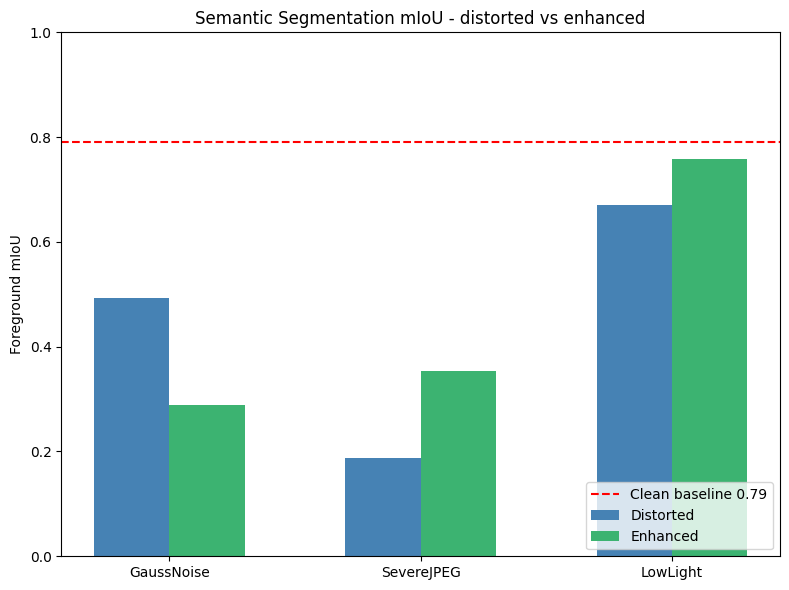

In [11]:
import cv2
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torchvision.datasets import VOCSegmentation
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

# 1. הגדרות בסיסיות (למקרה של איפוס הזיכרון)
SEED = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 2. טעינת מודל הסגמנטציה
weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = deeplabv3_resnet50(weights=weights).to(DEVICE)
seg_model.eval()
seg_transforms = weights.transforms()

# 3. פונקציות העיוות של מעיין והשחזור שלנו
def apply_gaussian_noise(img_pil, sigma=50, seed=SEED):
    img_np = np.array(img_pil.convert("RGB"), dtype=np.float32)
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0.0, scale=sigma, size=img_np.shape)
    return np.clip(img_np + noise, 0, 255).astype(np.uint8)

def apply_jpeg_compression(img_pil, quality=5):
    img_np = np.array(img_pil.convert("RGB"))
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    result, encimg = cv2.imencode('.jpg', cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR), encode_param)
    decimg = cv2.imdecode(encimg, 1)
    return cv2.cvtColor(decimg, cv2.COLOR_BGR2RGB)

def apply_low_light(img_pil, factor=0.15):
    img_np = np.array(img_pil.convert("RGB"), dtype=np.float32)
    return np.clip(img_np * factor, 0, 255).astype(np.uint8)

def restore_noise(img_np):
    bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    den = cv2.fastNlMeansDenoisingColored(bgr, None, 25, 25, 7, 35)
    den = cv2.bilateralFilter(den, d=9, sigmaColor=80, sigmaSpace=80)
    return cv2.cvtColor(den, cv2.COLOR_BGR2RGB)

def restore_jpeg(img_np):
    out = cv2.bilateralFilter(img_np, d=15, sigmaColor=100, sigmaSpace=100)
    return out

def restore_lowlight(img_np):
    gamma = 0.35
    lut = (np.arange(256) / 255.0) ** gamma * 255
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    img_gamma = cv2.LUT(img_np, lut)
    lab = cv2.cvtColor(img_gamma, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=6.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)

# 4. פונקציות להרצת המודל וחישוב מדדים
def compute_fg_iou(pred, gt, num_classes=21, ignore_index=255):
    valid = (gt != ignore_index)
    pred = pred[valid]
    gt = gt[valid]
    ious = []
    for c in range(1, num_classes):
        if (gt == c).sum() > 0:
            intersection = ((pred == c) & (gt == c)).sum().item()
            union = ((pred == c) | (gt == c)).sum().item()
            ious.append(intersection / union)
    return np.mean(ious) if len(ious) > 0 else np.nan

def predict_segmentation(img_pil):
    input_tensor = seg_transforms(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = seg_model(input_tensor)['out']
    output = F.interpolate(output, size=(img_pil.height, img_pil.width), mode='bilinear', align_corners=False)
    return output.argmax(1).squeeze(0).cpu().numpy()

# 5. טעינת נתונים
dataset = VOCSegmentation(root=DATA_DIR, year="2012", image_set="train", download=True)
selected_indices_path = RESULTS_DIR / "selected_indices.csv"
if selected_indices_path.exists():
    selected_indices_df = pd.read_csv(selected_indices_path)
    selected_indices = selected_indices_df["dataset_index"].tolist()
else:
    rng = np.random.default_rng(SEED)
    selected_indices = sorted(rng.choice(len(dataset), size=100, replace=False).tolist())

# 6. לולאת ההערכה
seg_results = {
    "GaussNoise": {"distorted": [], "enhanced": []},
    "SevereJPEG": {"distorted": [], "enhanced": []},
    "LowLight": {"distorted": [], "enhanced": []}
}
clean_ious = []

print("Starting DeepLabV3 Segmentation evaluation on 100 images...")

for idx in selected_indices:
    img_pil, gt_mask_pil = dataset[idx]
    gt_mask = np.array(gt_mask_pil)

    # בסיס (נקי)
    pred_clean = predict_segmentation(img_pil)
    clean_iou = compute_fg_iou(pred_clean, gt_mask)
    if not np.isnan(clean_iou):
        clean_ious.append(clean_iou)

    dist_rest_funcs = [
        ("GaussNoise", apply_gaussian_noise, restore_noise),
        ("SevereJPEG", apply_jpeg_compression, restore_jpeg),
        ("LowLight", apply_low_light, restore_lowlight)
    ]

    for dist_name, dist_func, rest_func in dist_rest_funcs:
        img_dist_np = dist_func(img_pil)
        img_enh_np = rest_func(img_dist_np)

        pred_dist = predict_segmentation(Image.fromarray(img_dist_np))
        pred_enh = predict_segmentation(Image.fromarray(img_enh_np))

        iou_dist = compute_fg_iou(pred_dist, gt_mask)
        iou_enh = compute_fg_iou(pred_enh, gt_mask)

        if not np.isnan(iou_dist): seg_results[dist_name]["distorted"].append(iou_dist)
        if not np.isnan(iou_enh): seg_results[dist_name]["enhanced"].append(iou_enh)

# 7. סיכום ויצירת גרף
clean_baseline_iou = np.mean(clean_ious)
seg_mean_results = {
    name: {
        "distorted": np.mean(data["distorted"]),
        "enhanced": np.mean(data["enhanced"])
    } for name, data in seg_results.items()
}

print("\n--- DeepLabV3 Foreground mIoU Results (Mean) ---")
print(f"Clean Baseline mIoU: {clean_baseline_iou:.3f}")
for name, data in seg_mean_results.items():
    print(f"{name}: Distorted = {data['distorted']:.3f}, Enhanced = {data['enhanced']:.3f}")

labels = list(seg_mean_results.keys())
dist_means = [seg_mean_results[l]["distorted"] for l in labels]
enh_means = [seg_mean_results[l]["enhanced"] for l in labels]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, dist_means, width, label='Distorted', color='steelblue')
ax.bar(x + width/2, enh_means, width, label='Enhanced', color='mediumseagreen')
ax.axhline(y=clean_baseline_iou, color='r', linestyle='--', label=f'Clean baseline {clean_baseline_iou:.2f}')

ax.set_ylabel('Foreground mIoU')
ax.set_title('Semantic Segmentation mIoU - distorted vs enhanced')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()
